# EDA CDC Places Dataset  

## Introduction

The Centers for Disease Control and Prevention (CDC) provides a dataset called "Places" that contains information about various health-related metrics at the county and city level across the United States. This dataset includes information on health outcomes, health behaviors, clinical care, social and economic factors, and physical environment.

This exploratory data analysis (EDA) focuses on understanding the structure of the CDC Places dataset, to identify patterns, trends, and potential areas for further analysis that can support the master dataset join. Key objectives include validating primary keys, identifying data quality issues (such as missingness), and assessing the distribution of core health metrics.

**Updated Version of the CDC Dataset**: The dataset has been updated to include age-adjusted rates for various health outcomes, which allows for more accurate comparisons across different populations. This update enhances the dataset's utility for public health research and policy-making.

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path 

# Read The CSV file 

In [2]:
base_path = Path.cwd().parents[1]  # Get the parent directory of the current working directory

data_path = base_path / "data" / "raw"/ "cdc_places_aa_raw.csv"

df = pd.read_csv(data_path)

print(f"Data loaded successfully")

Data loaded successfully


<positron-console-cell-2>:5: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.


In the CDC data, columns like countyfips or various demographic flags might contain both numbers (e.g., 6065) and potentially some "N/A" strings or leading zeros that cause the data type to switch from an int to an object/string.

In [3]:
# Specify columns explicitly
# Replace 'countyfips' with the actual column name that has mixed types
dtypes = {
    'countyfips': str,      # FIPS should always be a string to preserve leading zeros
    'bphigh_adjprev': float # Prevalence is a percentage
}

df = pd.read_csv(data_path, dtype=dtypes)

<positron-console-cell-3>:8: DtypeWarning: Columns (10,11) have mixed types. Specify dtype option on import or set low_memory=False.


Datatype warning is not coming from FIPS column 

In [4]:
# Peek at the columns to see what indices 10 and 11 are
cols = pd.read_csv(data_path, nrows=0).columns
print(f"Column 10: {cols[10]}")
print(f"Column 11: {cols[11]}")

Column 10: data_value_footnote_symbol
Column 11: data_value_footnote


These are messy columns, likly with a majority of null values. 

Since these are metadata/footnote columns, they likely won't be needed for actual machine-learning math anyway. The cleanest solution is to force them to strings so they don't interfere with your numeric data.

In [5]:
# Read the file by forcing the footnote columns to strings
df = pd.read_csv(
    data_path, 
    dtype={
        'data_value_footnote_symbol': str, 
        'data_value_footnote': str
    }
)

# Exploratory Data Analysis (EDA)

In [6]:
df.head()

,year,stateabbr,statedesc,locationname,datasource,category,measure,data_value_unit,data_value_type,data_value,...,low_confidence_limit,high_confidence_limit,totalpopulation,totalpop18plus,locationid,categoryid,measureid,datavaluetypeid,short_question_text,geolocation
0,2023,US,United States,NaN,BRFSS,Prevention,Current lack of health insurance among adults ...,%,Age-adjusted prevalence,11.5,...,11.2,11.9,334914895,262083034,59,PREVENT,ACCESS2,AgeAdjPrv,Health Insurance,NaN
1,2023,US,United States,NaN,BRFSS,Health Outcomes,Arthritis among adults,%,Age-adjusted prevalence,21.9,...,21.6,22.1,334914895,262083034,59,HLTHOUT,ARTHRITIS,AgeAdjPrv,Arthritis,NaN
2,2023,US,United States,NaN,BRFSS,Health Risk Behaviors,Binge drinking among adults,%,Age-adjusted prevalence,16.6,...,16.3,16.9,334914895,262083034,59,RISKBEH,BINGE,AgeAdjPrv,Binge Drinking,NaN
3,2023,US,United States,NaN,BRFSS,Health Outcomes,High blood pressure among adults,%,Age-adjusted prevalence,30.7,...,30.4,31.0,334914895,262083034,59,HLTHOUT,BPHIGH,AgeAdjPrv,High Blood Pressure,NaN
4,2023,US,United States,NaN,BRFSS,Prevention,Taking medicine to control high blood pressure...,%,Age-adjusted prevalence,57.5,...,56.8,58.2,334914895,262083034,59,PREVENT,BPMED,AgeAdjPrv,High Blood Pressure Medication,NaN


In [7]:
df.shape

(114649, 22)

This dataset has less features compared to the other CDC dataset previously downloaded. This is beacuse this dataset uses Wide Data instead of Long Data. Wide data has more columns and less rows. Long data has more rows and less columns. Wide data is GIS-friendly. 

This dataset will allow for cleaner merging, freatures ready for machine learning, and spatial integrity. 

In [8]:
print(df.columns)

Index(['year', 'stateabbr', 'statedesc', 'locationname', 'datasource',
       'category', 'measure', 'data_value_unit', 'data_value_type',
       'data_value', 'data_value_footnote_symbol', 'data_value_footnote',
       'low_confidence_limit', 'high_confidence_limit', 'totalpopulation',
       'totalpop18plus', 'locationid', 'categoryid', 'measureid',
       'datavaluetypeid', 'short_question_text', 'geolocation'],
      dtype='object')


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,114649.0,2022.862842,3.440153e-01,2022.0,2023.0,2023.0,2023.0,2023.0
data_value,114616.0,25.264020,2.122481e+01,1.7,9.5,17.8,33.3,90.4
low_confidence_limit,114616.0,22.318931,1.999225e+01,1.5,7.9,15.0,28.6,88.9
high_confidence_limit,114616.0,28.323929,2.240775e+01,2.0,11.3,20.8,38.3,91.8
totalpopulation,114649.0,223455.162138,6.261834e+06,43.0,10581.0,25915.0,69460.0,334914895.0
totalpop18plus,114649.0,174826.488194,4.900173e+06,30.0,8240.0,20528.0,54087.0,262083034.0
locationid,114649.0,30051.232353,1.526547e+04,59.0,18079.0,29151.0,45047.0,56045.0


The describe() output confirms the "Wide" structure by showing column-level summaries for the data.

The data_value Column: This confirms that the dataset is currently in a "Long-ish" format where data_value contains the measurement for the active metric, rather than having a column named bphigh_adjprev

In [10]:
df.isnull().sum()

year                               0
stateabbr                          0
statedesc                          0
locationname                      40
datasource                         0
category                           0
measure                            0
data_value_unit                    0
data_value_type                    0
data_value                        33
data_value_footnote_symbol    114609
data_value_footnote           114609
low_confidence_limit              33
high_confidence_limit             33
totalpopulation                    0
totalpop18plus                     0
locationid                         0
categoryid                         0
measureid                          0
datavaluetypeid                    0
short_question_text                0
geolocation                       40
dtype: int64

**Columns to be dropped**:

data_value	Drop Rows	Cannot predict hypertension without the data value.

locationname / geolocation	Likely minor reporting gaps; will disappear when you drop data_value rows.

low_confidence_limit / high_confidence_limit for BPHIGH describe the target's uncertainty — keep them out of the feature set (proposal flags dropping CI bounds).

technical/internal columns that add no value for ML: 'categoryid', 'datavaluetypeid', 'short_question_text', 'geolocation', 'datasource'

In [11]:
# Drop the columns that are 99% empty
df = df.drop(columns=['data_value_footnote', 'data_value_footnote_symbol', 'low_confidence_limit', 'high_confidence_limit'])

# Drop the 33 rows where 'data_value' is missing
# (This will also likely clean up the other small NaN counts like locationname)
df = df.dropna(subset=['data_value'])

# Drop the technical/internal columns that add no value for ML
df = df.drop(columns=['categoryid', 'datavaluetypeid', 'short_question_text', 'geolocation', 'datasource'])

df.isnull().sum()

year                0
stateabbr           0
statedesc           0
locationname       40
category            0
measure             0
data_value_unit     0
data_value_type     0
data_value          0
totalpopulation     0
totalpop18plus      0
locationid          0
measureid           0
dtype: int64

### Handle Measured and Measured ID columns 

Every measure (diabetes, obesity, smoking, BPHIGH...) is stacked in the same data_value column, distinguished by measureid. To get modeling target filter to measureid == "BPHIGH" (and datavaluetypeid == "AgeAdjPrv" for the county file), then pivot the remaining measures wide so each county is one row — with the BPHIGH value becoming your hypertension_prevalence target column and the other measures becoming candidate predictors.

In [12]:
# Check unique values in both columns
print("Unique values in 'measureid':")
print(df['measureid'].unique())

print("\nUnique values in 'measure':")
print(df['measure'].unique())

Unique values in 'measureid':
['ACCESS2' 'ARTHRITIS' 'BINGE' 'BPHIGH' 'BPMED' 'CANCER' 'CASTHMA' 'CHD'
 'CHECKUP' 'CHOLSCREEN' 'COGNITION' 'COLON_SCREEN' 'COPD' 'CSMOKING'
 'DENTAL' 'DEPRESSION' 'DIABETES' 'DISABILITY' 'EMOTIONSPT' 'FOODINSECU'
 'FOODSTAMP' 'GHLTH' 'HEARING' 'HIGHCHOL' 'HOUSINSECU' 'INDEPLIVE'
 'LACKTRPT' 'LONELINESS' 'LPA' 'MAMMOUSE' 'MHLTH' 'MOBILITY' 'OBESITY'
 'PHLTH' 'SELFCARE' 'SHUTUTILITY' 'SLEEP' 'STROKE' 'TEETHLOST' 'VISION']

Unique values in 'measure':
['Current lack of health insurance among adults aged 18-64 years'
 'Arthritis among adults' 'Binge drinking among adults'
 'High blood pressure among adults'
 'Taking medicine to control high blood pressure among adults with high blood pressure'
 'Cancer (non-skin) or melanoma among adults'
 'Current asthma among adults' 'Coronary heart disease among adults'
 'Visits to doctor for routine checkup within the past year among adults'
 'Cholesterol screening among adults' 'Cognitive disability among adults'
 'Colo

The primary intrest is BPHIGH (high blood pressure prevalence). 

measureid == "BPMED" (taking medicine to control high blood pressure) is the leakage trap noted in the proposal — it's essentially a downstream consequence of the target, so exclude it from predictors.

Additionly, there are SDoH (Social Determinats of Health) indicators 
    LACKTRPT (Lack of reliable transportation)

    FOODINSECU (Food insecurity)

    HOUSINSECU (Housing insecurity)

    LPA (No leisure-time physical activity)

    CSMOKING (Current smoking)

Create a Feature Selection list to keep model focused and reduce the noise. 

Consider the 5 core domains of SDoH (defined by Healthy People 2030): 

https://odphp.health.gov/healthypeople/priority-areas/social-determinants-health 

Economic Stability: FOODSTAMP (Receipt of food stamps). This is a strong proxy for household income levels.

Neighborhood & Built Environment: LPA (No leisure-time physical activity). Adding something like CASTHMA (Current asthma) or COPD could indirectly capture environmental factors like air quality or living conditions.

Health Care Access: ACCESS2 (Lack of health insurance) and CHECKUP (Routine checkups). These are vital because they track whether a patient can even get to the doctor to have their blood pressure managed.

Social & Community Context: LONELINESS and EMOTIONSPT (Lack of social/emotional support). Recent research is increasingly highlighting these as critical, often-overlooked factors in hypertension. Chronic stress from isolation is a powerful driver of BP.

Disability/Functionality:  MOBILITY, COGNITION, and SELFCARE. These are highly relevant, especially for the elderly population, as physical limitations often correlate with decreased ability to manage complex medical regimens.

In [13]:
# Core clinical and behavioral predictors
core_features = ['DIABETES', 'OBESITY', 'CSMOKING', 'LPA', 'SLEEP']

# SDoH and social context features
sdoh_features = ['LACKTRPT', 'FOODINSECU', 'HOUSINSECU', 'FOODSTAMP', 
'ACCESS2', 'GHLTH','CASTHMA', 'COPD','LONELINESS', 'EMOTIONSPT',]

# Aging and disability proxies
aging_features = ['MOBILITY', 'COGNITION', 'SELFCARE', 'TEETHLOST', 'VISION']

# Combine for the final list
selected_measures = ['BPHIGH'] + core_features + sdoh_features + aging_features

# Filter your dataframe
df_filtered = df[df['measureid'].isin(selected_measures)]

## Piviot the Dataframe

To merge the dataset a common key is needed. df_wide will have a row per county where a left_join can be performed with the master dataset. The data_value column will be pivoted into new columns for each metric, with the values being the corresponding data_value.

In [14]:
# Pivot the data to create columns for each measure
df_wide = df_filtered.pivot_table(
    index=['locationid', 'locationname', 'stateabbr'], 
    columns='measureid', 
    values='data_value'
).reset_index()

# Now your columns will be the actual health measures (e.g., 'High blood pressure')
print(df_wide.columns)

Index(['locationid', 'locationname', 'stateabbr', 'ACCESS2', 'BPHIGH',
       'CASTHMA', 'COGNITION', 'COPD', 'CSMOKING', 'DIABETES', 'EMOTIONSPT',
       'FOODINSECU', 'FOODSTAMP', 'GHLTH', 'HOUSINSECU', 'LACKTRPT',
       'LONELINESS', 'LPA', 'MOBILITY', 'OBESITY', 'SELFCARE', 'SLEEP',
       'TEETHLOST', 'VISION'],
      dtype='object', name='measureid')


In [15]:
df = df_wide.copy()  # Use the wide format for further analysis

In [16]:
df.shape

(3143, 24)

In [17]:
df.isnull().sum()

measureid
locationid        0
locationname      0
stateabbr         0
ACCESS2         187
BPHIGH          187
CASTHMA         187
COGNITION       187
COPD            187
CSMOKING        187
DIABETES        187
EMOTIONSPT      844
FOODINSECU      844
FOODSTAMP       844
GHLTH           187
HOUSINSECU      844
LACKTRPT        844
LONELINESS      844
LPA             187
MOBILITY        187
OBESITY         187
SELFCARE        187
SLEEP             0
TEETHLOST         0
VISION          187
dtype: int64

The "0" counts: These measures (e.g., All teeth lost, Colorectal cancer screening, Short sleep duration) have zero missing values. Data is perfectly complete for these.

The "187" counts: These are standard health metrics (like High blood pressure). They have 187 missing rows across the entire dataset. It is highly likely that there are 187 counties (out of 3,143 total) that were excluded from the CDC's survey due to small population sizes or missing data

The "844" counts: These are social determinant metrics (like Food insecurity, Housing insecurity). They have 844 missing rows. Suggests that these specific questions were likely added to the survey more recently or were only asked in specific demographic subsets, leading to more missing entries.

The remaining 187 and 844 counts of NaN (missing) values in the columns are now "feature gaps." In machine learning, will have to choose how to handle these before can train your hypertension model.

In [18]:
df.head()

measureid,locationid,locationname,stateabbr,ACCESS2,BPHIGH,CASTHMA,COGNITION,COPD,CSMOKING,DIABETES,...,HOUSINSECU,LACKTRPT,LONELINESS,LPA,MOBILITY,OBESITY,SELFCARE,SLEEP,TEETHLOST,VISION
0,1001,Autauga,AL,9.1,38.2,10.0,15.9,6.4,14.5,11.4,...,13.2,8.9,33.7,26.0,13.4,39.5,3.6,37.7,12.0,4.8
1,1003,Baldwin,AL,8.8,37.0,9.4,15.1,6.0,13.3,10.4,...,11.0,7.5,33.3,23.7,12.3,35.0,3.2,36.4,11.4,4.3
2,1005,Barbour,AL,14.8,45.4,10.9,20.3,9.3,20.8,16.5,...,23.2,15.6,39.8,34.5,20.0,47.1,6.4,44.6,27.7,8.4
3,1007,Bibb,AL,13.0,42.4,10.4,19.6,8.9,19.9,13.9,...,17.2,12.2,37.2,31.9,17.4,43.7,5.1,41.4,21.7,6.7
4,1009,Blount,AL,12.0,36.0,9.9,18.0,7.6,16.9,11.3,...,13.1,9.2,35.8,27.7,14.5,36.0,4.0,37.6,16.8,5.3


In [19]:
df.dtypes

measureid
locationid        int64
locationname     object
stateabbr        object
ACCESS2         float64
BPHIGH          float64
CASTHMA         float64
COGNITION       float64
COPD            float64
CSMOKING        float64
DIABETES        float64
EMOTIONSPT      float64
FOODINSECU      float64
FOODSTAMP       float64
GHLTH           float64
HOUSINSECU      float64
LACKTRPT        float64
LONELINESS      float64
LPA             float64
MOBILITY        float64
OBESITY         float64
SELFCARE        float64
SLEEP           float64
TEETHLOST       float64
VISION          float64
dtype: object

All your measures are correctly formatted as float64 and are ready for mathematical operations 

Still have NaN values represented as float64 columns. 

In [20]:
# Check how many unique counties you have now
print(f"Total unique counties: {df['locationid'].nunique()}")

# Ensure there are no rows that have ONLY NaNs (which would mean a failed pivot for that row)
print(f"Rows with all NaN values: {df.drop(columns=['locationid', 'locationname', 'stateabbr']).isnull().all(axis=1).sum()}")

Total unique counties: 3143
Rows with all NaN values: 0


successfully created a robust, "wide" feature matrix, with 3,143 unique counties and zero rows composed entirely of NaNs

## Target Variable

The target variable for this analysis is the estimated prevalence of High blood pressure among adults (High blood pressure among adults) BPHIGH, derived from the CDC PLACES dataset. These values represent model-based estimates generated via the Behavioral Risk Factor Surveillance System (BRFSS) and Census-level data.

Key Analytical Considerations:

    Nature of Data: These are statistically modeled estimates, not direct survey counts. They are designed for identifying broad geographic health disparities rather than evaluating the immediate impact of local interventions.

    Crude vs. Age-Adjusted: Our analysis will primarily utilize Age-Adjusted values. While "Crude" rates reflect the raw percentage of the population affected, age-adjusted rates normalize for differences in age distribution across counties, allowing for a fairer, more accurate comparison of health burdens between counties with different demographics.

    Granularity: With our data pivoted to the county level (locationid), we will examine the spatial distribution and variance of hypertension prevalence to identify trends that may serve as strong predictors for our risk stratification model.

In [21]:
# Descriptive statistics for target
# This tells you the min, max, mean, and spread of HBP across all 3,143 counties
target_col = 'BPHIGH'
print(df[target_col].describe())

count    2956.000000
mean       33.537483
std         4.654139
min        21.000000
25%        30.100000
50%        32.800000
75%        36.300000
max        53.100000
Name: BPHIGH, dtype: float64


2,956 out of 3,143 counties reporting this data, which is a high completion rate—excellent for modeling

the mean is close to the median, indicating normal distribution. Models won't have to struggle to extream skewness. 

There is also a healthy amount of variance with a standard deviation of 4.65%. The model should have room to distinguish between high-risk and low risk counties. 

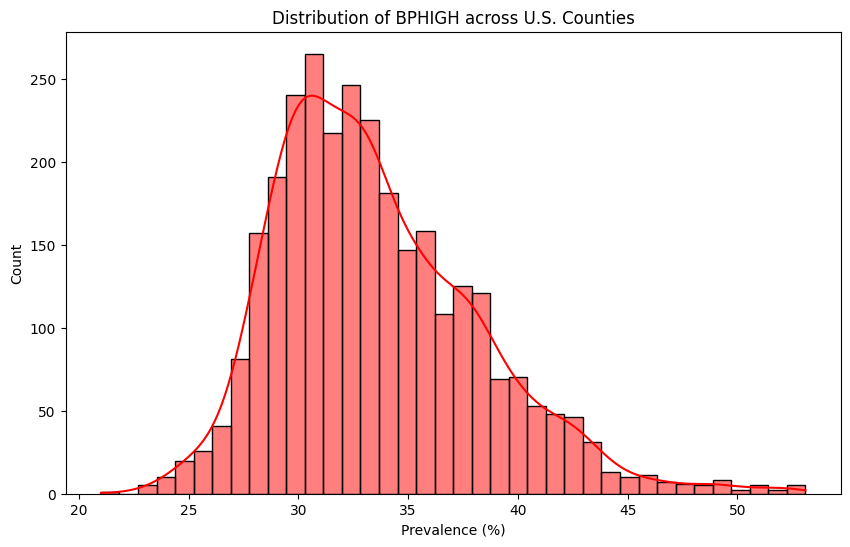

In [22]:
# Visualize the distribution

plt.figure(figsize=(10, 6))
sns.histplot(df[target_col], kde=True, color='red')
plt.title(f'Distribution of {target_col} across U.S. Counties')
plt.xlabel('Prevalence (%)')
plt.show()

While the mean and median were very close, a simple summary statistic can sometimes hide asymmetry (skewness) or "fat tails" in the distribution. Data likly has high-prevalence outliers. 

While most counties hover in the 30% range, there is a distinct subset of counties suffering from significantly worse health outcomes, which is exactly what a "Risk Atlas" should highlight.

In [23]:
# Calculate skewness
skew_val = df['BPHIGH'].skew()
print(f"Skewness coefficient: {skew_val:.2f}")

Skewness coefficient: 0.83


In [24]:
# Quick check for outliers
# High-prevalence counties (Top 5)
print(df_wide.nlargest(5, target_col)[['locationname', 'stateabbr', target_col]])

measureid  locationname stateabbr  BPHIGH
1428             Holmes        MS    53.1
1132       East Carroll        LA    52.5
5               Bullock        AL    52.4
31               Greene        AL    52.4
1429          Humphreys        MS    52.4


The high-prevalence counties represent some of the most concentrated areas of cardiovascular risk in the United States.

It is not a coincidence that these counties appear together at the top of the list. They are all situated within the "Stroke Belt" or the Mississippi Delta region, where historical, socio-economic, and environmental factors converge to create some of the nation's most persistent health disparities.

## HeatMap of Hypertension Prevalence

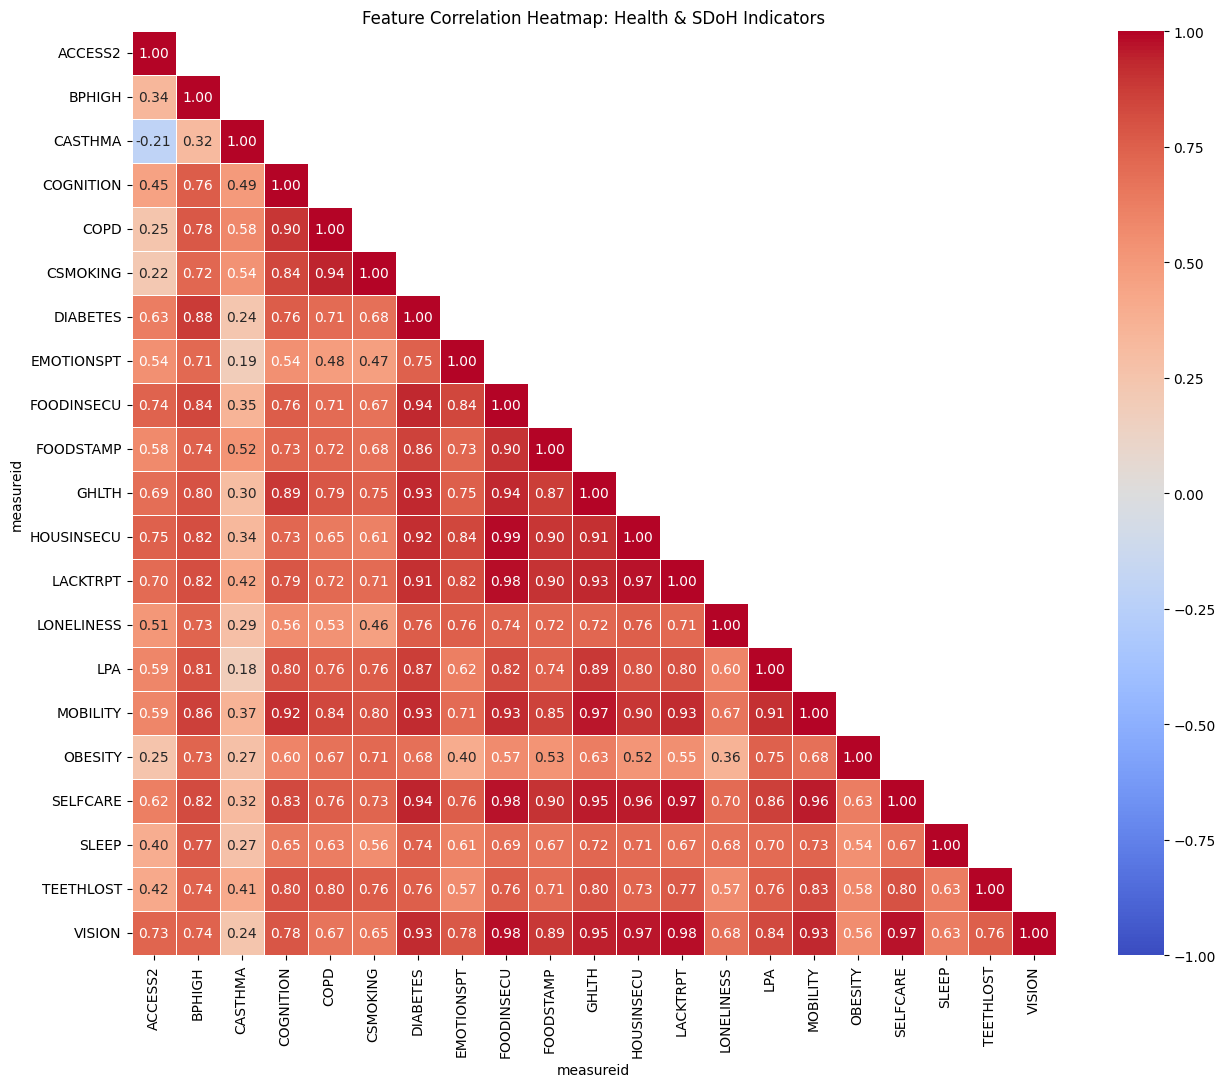

In [25]:
features = ['ACCESS2', 'BPHIGH',
       'CASTHMA', 'COGNITION', 'COPD', 'CSMOKING', 'DIABETES', 'EMOTIONSPT',
       'FOODINSECU', 'FOODSTAMP', 'GHLTH', 'HOUSINSECU', 'LACKTRPT',
       'LONELINESS', 'LPA', 'MOBILITY', 'OBESITY', 'SELFCARE', 'SLEEP',
       'TEETHLOST', 'VISION']

# Calculate the correlation matrix
corr = df[features].corr(numeric_only=True)

# Create a mask to hide the upper triangle
# np.triu returns the upper triangle, k=1 keeps the diagonal visible
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

# Set up the matplotlib figure
plt.figure(figsize=(16, 12))

# Create the heatmap
sns.heatmap(
    corr, 
    mask=mask,            
    annot=True,         
    fmt=".2f",           
    cmap='coolwarm',    
    vmin=-1, vmax=1,     
    center=0,            
    linewidths=0.5,     
    square=True 
)

plt.title('Feature Correlation Heatmap: Health & SDoH Indicators')
plt.show()

In [26]:
# See what is most strongly related to your target
print(corr['BPHIGH'].sort_values(ascending=False))

measureid
BPHIGH        1.000000
DIABETES      0.876326
MOBILITY      0.864986
FOODINSECU    0.837929
SELFCARE      0.822106
HOUSINSECU    0.815661
LACKTRPT      0.815566
LPA           0.810299
GHLTH         0.804601
COPD          0.777273
SLEEP         0.768266
COGNITION     0.759909
FOODSTAMP     0.743519
VISION        0.735637
TEETHLOST     0.735246
OBESITY       0.732212
LONELINESS    0.729894
CSMOKING      0.719473
EMOTIONSPT    0.713900
ACCESS2       0.341459
CASTHMA       0.319853
Name: BPHIGH, dtype: float64


The "Top Tier" (Strongest Drivers): DIABETES (0.87) and MOBILITY (0.86) are heavy hitters. The fact that MOBILITY (a disability/functionality metric) is nearly as strong as DIABETES (a metabolic disease) is a fascinating finding. It suggests that physical limitations are just as strongly associated with hypertension as biological risk factors.

The "Structural" Group: FOODINSECU (0.83), HOUSINSECU (0.81), and LACKTRPT (0.81) are all extremely high. This validates the original hypothesis: SDoH are not just "background noise"; they are statistically comparable to medical risk factors.

The "Low Correlation" Group: ACCESS2 (0.34) and CASTHMA (0.31) are much lower than the rest. This doesn't mean they aren't important; it means they are independent—they track with hypertension differently than the other factors.

# Save the processed dataset

Use dataset for pipeline integration and future modeling. This step ensures that the cleaned and transformed data is readily available for subsequent analysis, reducing the need for repeated preprocessing.

In [28]:
# Path setup
base_path = Path.cwd().parents[1]
processed_dir = base_path / "data" / "processed" 

# Ensure the folder exists (best practice)
processed_dir.mkdir(parents=True, exist_ok=True)

In [30]:
# Save your CDC file
cdc_file = processed_dir / "processed_cdc_data.csv"
df_wide.to_csv(cdc_file, index=False)

print(f"File saved successfully")

File saved successfully
